In [201]:
import numpy as np
import time
from ground_truth.utility_methods import *
from ground_truth.visualization import *
from ground_truth.save import *
from ground_truth.dataloader import *
import ground_truth.feature_extraction as ft

def process_image(image_dir, image_id, frame_str, net, device,
            depth_thresh=125, normal_thresh=1.25 * 1e7, thickness=1, structural_thresh=0.6,
            method="neighborhood", normal_func=np.max, depthfunc=np.max,
            depth_normal_func_str="Max", norm_agg_func=np.linalg.norm,
            struct_color=(0, 0, 255), text_color=(255, 0, 0), normal_k_size=11, dataset="hypersim", moge_model= None):

    # Load image data using helper functions.
    cam_view_color = "scene_cam_00_final_preview"
    cam_view_geom = "scene_cam_00_geometry_hdf5"
    gt = "gt"
    moge = "moge"
    frame_str = "0001"
   

    if dataset == "hypersim":
        image_dir = os.path.join("data", image_id)
        hypersim_loader = HypersimLoader(image_dir) # Base dir contains scenes
        color_img = hypersim_loader.load_color_image(image_id, frame_str, cam_view_color)
        depth_map = hypersim_loader.load_depth_map(image_id, frame_str, cam_view_geom)
        
        seconds = time.time()
        print("Start :", seconds)	
        # color_img = load_color_image(image_dir, image_id, frame_str, cam_view_color)
        #h, w = color_img.shape
        #normal_map = load_normal_map(image_dir, image_id, frame_str, cam_view_geom)
        # depth_map = load_depth_map(image_dir, image_id, frame_str, cam_view_geom)
        h, w = depth_map.shape
        fov_x = np.pi / 3 
        f = w / (2 * np.tan(fov_x / 2))
        default_K = np.array([[f, 0, w / 2], [0, f, h / 2], [0, 0, 1]])
     
        depth_map = raydepth2depth(depth_map, default_K)
        # depth_map = depth_map.astype(np.float32)
        #world_coordinates_map = load_world_coordinates(image_dir, image_id, frame_str, cam_view_geom)

        # normal_map = calculate_normal_map_from_depth(depth_map, ksize=1)
        # plot_images([normal_map], ["Normal Original"], cmaps='gray')    
        
        
        # Reconstruct the 3D world coordinates from depth.
        world_coordinates_map = reproject_depth_to_points(depth_map, default_K)

        # ---------------------------
        # Reprojection & Enhanced Plotting

        # Reproject depth to 3D points.

        # Compute the normal map from the reprojected 3D points.
        normal_map_reprojected = compute_normal_map_from_points(world_coordinates_map,  ksize=1)

        

        ###############################################################################################################################################
        normal_map = normal_map_reprojected#hypersim_loader.load_normal_map(image_id, frame_str, cam_view_geom)

        seconds2 = time.time()
        print("Time to get depth and calculate normal map and wd :", seconds2- seconds)
        seconds2 = time.time()

        #normal_gray = cv2.cvtColor(normal_map, cv2.COLOR_BGR2GRAY)
        
        
        # Detect lines with DeepLSD.
        gray_img = cv2.cvtColor(color_img, cv2.COLOR_RGB2GRAY)
        # Detect lines with DeepLSD
        # global df_intermediate_features
        # global angle_intermediate_features
        df_intermediate_features = None
        angle_intermediate_features = None 
        df_hook_handle = net.df_head[5].register_forward_hook(ft.hook_df)
        angle_hook_handle = net.angle_head[5].register_forward_hook(ft.hook_angle)
        input_tensor = torch.tensor(gray_img, dtype=torch.float32, device=device)[None, None] / 255.
        with torch.no_grad():
            out = net({'image': input_tensor})
            pred_lines = out['lines'][0]
            if isinstance(pred_lines, torch.Tensor):
                pred_lines = pred_lines.cpu().numpy()
                
        # get embeddings for intermediate layers.
        combined_features = torch.cat([ft.df_intermediate_features, ft.angle_intermediate_features], dim=1)
        downsample_ratio = color_img.shape[1] / combined_features.shape[3]
        df_hook_handle.remove()
        angle_hook_handle.remove()
        seconds3 = time.time()
        print("Time for DeepLSD :", seconds3- seconds2) 
        ##connected compement
        
        kernel_close_n = np.ones((3, 3), np.uint8)
        
        sobel_normal = compute_variation(normal_map,k = 27)
        sobel_normal = np.linalg.norm(sobel_normal, axis=2)
        thresh_normal = threshold_edges(sobel_normal, thresh_val= 82000000000000)#50000, 40000, 77000000000000
        thresh_normal = cv2.convertScaleAbs(thresh_normal)
        kernel = np.ones((3, 3), np.uint8)

        thresh_normal = cv2.morphologyEx(thresh_normal, cv2.MORPH_CLOSE, kernel_close_n)

        thresh_normal = cv2.erode(thresh_normal, kernel, iterations=2)
        
        
        kernel_close_d = np.ones((3, 3), np.uint8)

        # depth_map = load_depth_map(image_dir, image_id, frame_str, cam_view_geom)
        # depth_map = raydepth2depth(depth_map, default_K)
        sobel_depth = compute_variation_laplace(depth_map,k=3, depth=True)
        thresh_depth = threshold_edges(sobel_depth, thresh_val=0.2)#0.07, 0.6
        thresh_depth = cv2.convertScaleAbs(thresh_depth)
        
        thresh_depth = cv2.morphologyEx(thresh_depth, cv2.MORPH_CLOSE, kernel_close_d)
        kernel_dilate_d = np.ones((3, 3), np.uint8)
        thresh_depth = cv2.dilate(thresh_depth, kernel_dilate_d, iterations=3)

        #thresh_depth = cv2.erode(thresh_depth, kernel, iterations=1)
        
        

        combined_edges = cv2.bitwise_or(thresh_normal, thresh_depth)
        
        
        
        
        
        combined_edges = np.nan_to_num(combined_edges, nan=0.0)


        seconds4 = time.time()
        print("Time to calculate variation edges :", seconds4 - seconds3) 
        
        # Classify each predicted line.
        is_struct = []
        is_depth_seperated  = []
      

        for l in pred_lines:
            masked_depth, masked_normal = sobel_line(thresh_depth, thresh_normal, l)

            line_fully_on_depth = np.any(masked_depth)
            line_fully_on_normal = np.any(masked_normal)
            is_struct.append(line_fully_on_depth or line_fully_on_normal)
            is_depth_seperated.append(line_fully_on_depth)
        
        seconds5 = time.time()
        print("Time for structural vs textural :", seconds5 - seconds4)   
        seconds5 = time.time()

        """"""
      
        non_structural_color = text_color
        structural_color1 = (128, 0, 128)  # purple
        structural_color2 = (0, 165, 255)   # orange

        composite_after = color_img.copy()
        new_lines_list = []  # List of all drawn lines (offsets for structural, original for textural)
        line_info = []       # Metadata for each base line

        for i, l in enumerate(pred_lines):
            
            line = l.reshape(2, 2) if l.shape == (4,) else l
            #line_embedding = ft.sample_line_features(combined_features, line, num_samples=10, downsample_ratio=downsample_ratio)

            # Case 1: Structural line in low depth variation => split
            if True:
                idx = len(new_lines_list)
                new_lines_list.append(line)
                line_info.append({
                    "base_line": line.tolist(),
                    "score": 1 if is_struct[i] else 0,
                    "new_line_indices": [idx],
                    #"line_embedding": line_embedding.tolist()

                })
                cv2.line(composite_after,
                        (int(round(line[0, 0])), int(round(line[0, 1]))),
                        (int(round(line[1, 0])), int(round(line[1, 1]))),
                        non_structural_color, thickness)


    
        
        composite_after_rgb = cv2.cvtColor(composite_after, cv2.COLOR_BGR2RGB)
        
        seconds6 = time.time()
        print("Time for line data structure creation :", seconds6 - seconds5)  
        

        kernel_combine = np.ones((3, 3), np.uint8)
        kernel_open = np.ones((2,2), np.uint8)
        kernel_close = np.ones((2, 2), np.uint8)


        #combined_edges = cv2.dilate(combined_edges, kernel_combine, iterations=1)
        binary_mask = cv2.bitwise_not(combined_edges)
        
        # Apply morphological closing to fill small holes in the regions.
        binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel_close)
        binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel_open)


        num_labels, labels_im = cv2.connectedComponents(binary_mask)

        seconds7 = time.time()
        print("Time to get CC :", seconds7- seconds6) 
        print("Number of connected components (including background):", num_labels)
        seconds7 = time.time()


        #########################################
        # RANSAC Plane Fitting Per Component
        #########################################
        min_points = 50  # Only consider clusters with enough points.
        cluster_planes = {}  # Store valid plane parameters for each cluster.
        for label in np.unique(labels_im):
            if label == 0:
                continue  # Skip the background.
            indices = (labels_im == label)
            points = world_coordinates_map[indices]
            if points.shape[0] < min_points:
                continue
            model, inliers_mask = ransac_plane_fit(points, num_iterations=50, threshold=0.02, min_inliers_ratio=0.8)
            if model is None:
                #print(f"Cluster {label}: no valid plane model found.")
                continue
            inlier_points = points[inliers_mask]
            errors = compute_distance_to_plane(inlier_points, model[0], model[1])
            mean_error = np.mean(errors)
            if mean_error > 0.05:
                #print(f"Cluster {label}: mean error {mean_error:.4f} too high, skipped as non-planar.")
                continue
            # Refine using a least-squares fit.
            A = np.c_[inlier_points[:, 0], inlier_points[:, 1], np.ones(inlier_points.shape[0])]
            B = inlier_points[:, 2]
            sol, _, _, _ = np.linalg.lstsq(A, B, rcond=None)
            normal_ls = np.array([sol[0], sol[1], -1])
            normal_ls = normal_ls / np.linalg.norm(normal_ls)
            d_ls = sol[2]
            cluster_planes[label] = {
                'ransac_model': model,
                'ls_model': (normal_ls, d_ls),
                'inliers_mask': inliers_mask,
                'mean_error': mean_error
            }
            #print(f"Cluster {label}: valid plane with mean error {mean_error:.4f}.")

        seconds8 = time.time()
        print("Time to run Ransac :", seconds8- seconds7) 
        print("Number of connected components (including background):", num_labels)
        seconds8 = time.time()

        #########################################
        # Filtering of Valid Clusters
        #########################################
        # Create a new label map that retains only clusters with valid plane fits.
        new_label_map = np.copy(labels_im)
        for label in np.unique(labels_im):
            if label != 0 and label not in cluster_planes:
                new_label_map[new_label_map == label] = 0    
        #########################################
        # Define the Plane Similarity Criterion
        #########################################
        def are_planes_similar(plane1, plane2, normal_threshold=0.98, distance_threshold=0.02):
            n1, d1 = plane1['ls_model']
            n2, d2 = plane2['ls_model']
            if np.abs(np.dot(n1, n2)) < normal_threshold:
                return False
            if np.abs(d1 - d2) > distance_threshold:
                return False
            return True
        
        #########################################
        # Build a Region Adjacency Graph (RAG)
        #########################################
        # Use only valid labels (those that exist in your cluster_planes).
        valid_labels = list(cluster_planes.keys())

        # Create the graph with nodes corresponding to valid plane clusters.
        G = nx.Graph()
        for label in valid_labels:
            G.add_node(label, plane=cluster_planes[label]['ls_model'])  # you can also store more data if needed


        # Precompute binary masks and their dilations
        masks = {}
        dilated_masks = {}
        kernel = np.ones((12, 12), np.uint8)
        for label in valid_labels:
            mask = (new_label_map == label).astype(np.uint8)
            masks[label] = mask
            dilated_masks[label] = cv2.dilate(mask, kernel, iterations=7)

        # For each pair of valid clusters, add an edge if they are touching and their plane parameters are similar.

        for i, label1 in enumerate(valid_labels):
            for label2 in valid_labels[i+1:]:
                # Check if clusters touch using precomputed dilated mask
                if np.any(cv2.bitwise_and(dilated_masks[label1], masks[label2])) and \
                are_planes_similar(cluster_planes[label1], cluster_planes[label2],
                                    normal_threshold=0.98, distance_threshold=0.02):
                    G.add_edge(label1, label2)

        # The connected components of the graph are the merged groups.
        merged_groups = list(nx.connected_components(G))
        #print("Merged plane groups (via RAG):", merged_groups)

        #########################################
        # Create the Merged Label Map from the Graph
        #########################################
        merged_map = np.zeros_like(labels_im)
        new_label = 1
        for group in merged_groups:
            for label in group:
                merged_map[labels_im == label] = new_label
            new_label += 1
        seconds9 = time.time()
        print("Time to filter and merge plans :", seconds9- seconds8) 
        print("Time before plotting :", seconds9- seconds) 
        #########################################
        # Final Visualization (Subplots as Requested)
        #########################################
        # Connected components visualization.
        np.random.seed(20)
        label_colors = np.random.randint(0, 255, size=(num_labels, 3), dtype=np.uint8)
        colored_img = label_colors[labels_im]
        colored_img[labels_im == 0] = [0, 0, 0]

        # Visualization for valid (planar) clusters.
        label_colors_new = np.random.randint(0, 255, size=(num_labels, 3), dtype=np.uint8)
        colored_new = label_colors_new[new_label_map]
        colored_new[new_label_map == 0] = [0, 0, 0]

        # Visualization for merged clusters.
        label_colors_merged = np.random.randint(0, 255, size=(num_labels, 3), dtype=np.uint8)
        colored_merged = label_colors_merged[merged_map]
        colored_merged[merged_map == 0] =  [0, 0, 0]

        #########################################
        # Additional Visualization: Dilated Connected Components
        # For this image, we dilate each nonzero connected component (leaving cluster 0 unchanged)
        #########################################
        kernel_dilate_custom = np.ones((3, 3), np.uint8)
        dilated_map = np.copy(merged_map)
        for lbl in np.unique(merged_map):
            if lbl != 0:
                mask_lbl = (merged_map == lbl).astype(np.uint8)
                dilated_mask = cv2.dilate(mask_lbl, kernel_dilate_custom, iterations=3)
                dilated_map[dilated_mask == 1] = lbl


        np.random.seed(20)
        label_colors_dilated = np.random.randint(0, 255, size=(num_labels, 3), dtype=np.uint8)
        colored_dilated = label_colors_dilated[dilated_map]
        colored_dilated[dilated_map == 0] = [255, 255, 255]
        
        
        line_labels = find_line_planes(new_lines_list, dilated_map, get_line_pixels_trim)

        coplanarity_labels_original_lines = []
        # Update each line_info entry with its corresponding coplanarity labels.
        for entry in line_info:
            indices = entry.pop("new_line_indices")  # Remove indices after use
            if len(indices) == 1:
                coplanarity_labels_original_lines.append([line_labels[indices[0]]])
                entry["coplanarity_labels"] = line_labels[indices[0]]
            else:
                coplanarity_labels_original_lines.append([line_labels[i] for i in indices])
                entry["coplanarity_labels"] = [line_labels[i] for i in indices]

        # Create coplanar matrix.
        N = len(coplanarity_labels_original_lines)
        coplanarity_matrix = np.zeros((N, N), dtype=int)

        for i in range(N):
            for j in range(N):
                for label in coplanarity_labels_original_lines[i]:
                    if label in coplanarity_labels_original_lines[j] and label != -1 and label != 0:
                        coplanarity_matrix[i, j] = 1



        #save to json
        #save_lines_to_json(image_id, line_info, coplanarity_matrix)
        
        plt.figure(figsize=(15, 10))
        plt.subplot(2, 2, 1)
        plt.title('Depth Map')
        plt.imshow(depth_map, cmap='gray')
        plt.axis('off')

        plt.subplot(2, 2, 2)
        plt.title('Normal Map from Depth')
        plt.imshow((normal_map_reprojected+ 1)/2, cmap='gray')
        plt.axis('off')
        plt.subplot(2, 2, 3)
        plt.title('Sobel on Depth Map')
        plt.imshow(sobel_depth, cmap='gray')
        plt.axis('off')

        plt.subplot(2, 2, 4)
        plt.title('Sobel on Normal Map')
        plt.imshow(sobel_normal, cmap='gray')
        plt.axis('off')

        plt.show()




        plt.figure(figsize=(15, 10))

        plt.subplot(2, 2, 1)
        plt.title('Thresholded Depth Edges')
        plt.imshow(thresh_depth, cmap='gray')
        plt.axis('off')

        plt.subplot(2, 2, 2)
        plt.title('Thresholded Normal Edges')
        plt.imshow(thresh_normal, cmap='gray')
        plt.axis('off')

        plt.subplot(2, 2, 3)
        plt.title('Combined Edges')
        plt.imshow(combined_edges, cmap='gray')
        plt.axis('off')


        ax5 = plt.subplot(2, 2, 4)
        plt.title('Line Matches')
        plt.axis('off')
        plot_lines_bool(ax5, color_img, pred_lines, is_correct=   [not x for x in is_struct])


        plt.show()


        plt.figure(figsize=(20, 15))

        plt.subplot(4, 3, 1)
        plt.title('Combined Edges')
        plt.imshow(combined_edges, cmap='gray')
        plt.axis('off')

        plt.subplot(4, 3, 2)
        plt.title('Connected Components')
        plt.imshow(cv2.cvtColor(colored_img, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        
        plt.subplot(4, 3, 3)
        plt.title('Connected Components')
        plt.imshow(cv2.cvtColor(colored_img, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.subplot(4, 3, 4)
        plt.title('CC without nonplanar clusters')
        plt.imshow(cv2.cvtColor(colored_new, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.subplot(4, 3, 5)
        plt.title('CC without nonplanar clusters and merged planes')
        plt.imshow(cv2.cvtColor(colored_merged, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        """
        plt.subplot(4, 3, 6)
        plt.title('Dilated')
        plt.imshow(cv2.cvtColor(colored_dilated, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        """
        ax11 = plt.subplot(4, 3, 6)
        plt.title('Line coplanarity')
        plot_coplanar_lines(ax11, new_lines_list, line_labels, color_img)
        plt.axis('off')

        plt.subplot(4, 3, 8)
        plt.title('Original Image')
        plt.imshow(cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()



                
    return None, None, None, None, None, None, None, None, None, None   


In [202]:
import numpy as np
import cv2
import hdbscan
from sklearn.neighbors import NearestNeighbors
from sklearn.impute import SimpleImputer
import numpy as np
import matplotlib.pyplot as plt
import hdbscan
import matplotlib
import random
import os
import json
import torch 
import h5py
import glob
from numpy import linalg as LA

random.seed(10)

# Exploration

In [203]:
import os
import torch
from deeplsd.models.deeplsd_inference import DeepLSD


In [204]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
conf = {'detect_lines': True, 'line_detection_params': {'merge': False, 'filtering': True, 'grad_thresh': 3}}
ckpt = torch.load('../weights/deeplsd_md.tar', map_location='cpu', weights_only=False)
net = DeepLSD(conf)
net.load_state_dict(ckpt['model'])
net = net.to(device).eval()


Start : 1744831228.053306
???
Time to get depth and calculate normal map and wd : 0.06981563568115234
Time for DeepLSD : 0.6154415607452393
Time to calculate variation edges : 0.07453131675720215
Time for structural vs textural : 0.07050895690917969
Time for line data structure creation : 0.0024559497833251953
Time to get CC : 0.0010106563568115234
Number of connected components (including background): 42
Time to run Ransac : 0.31401824951171875
Number of connected components (including background): 42
Time to filter and merge plans : 0.0688776969909668
Time before plotting : 1.216865062713623


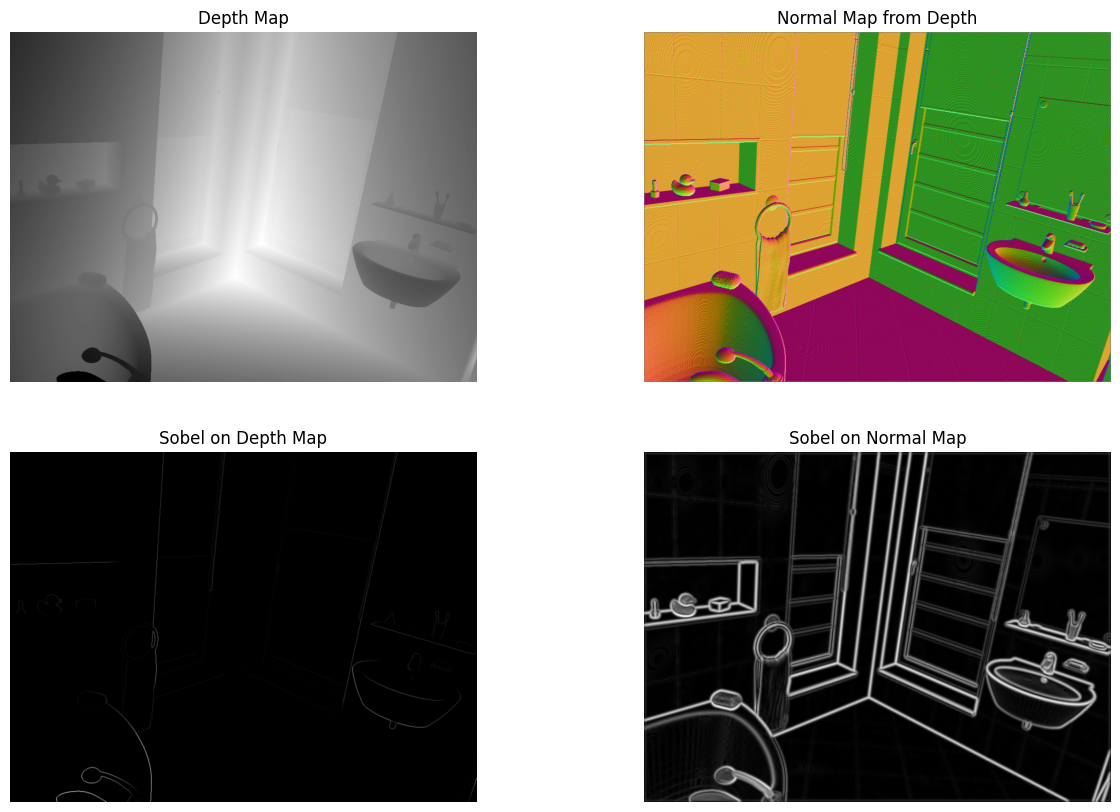

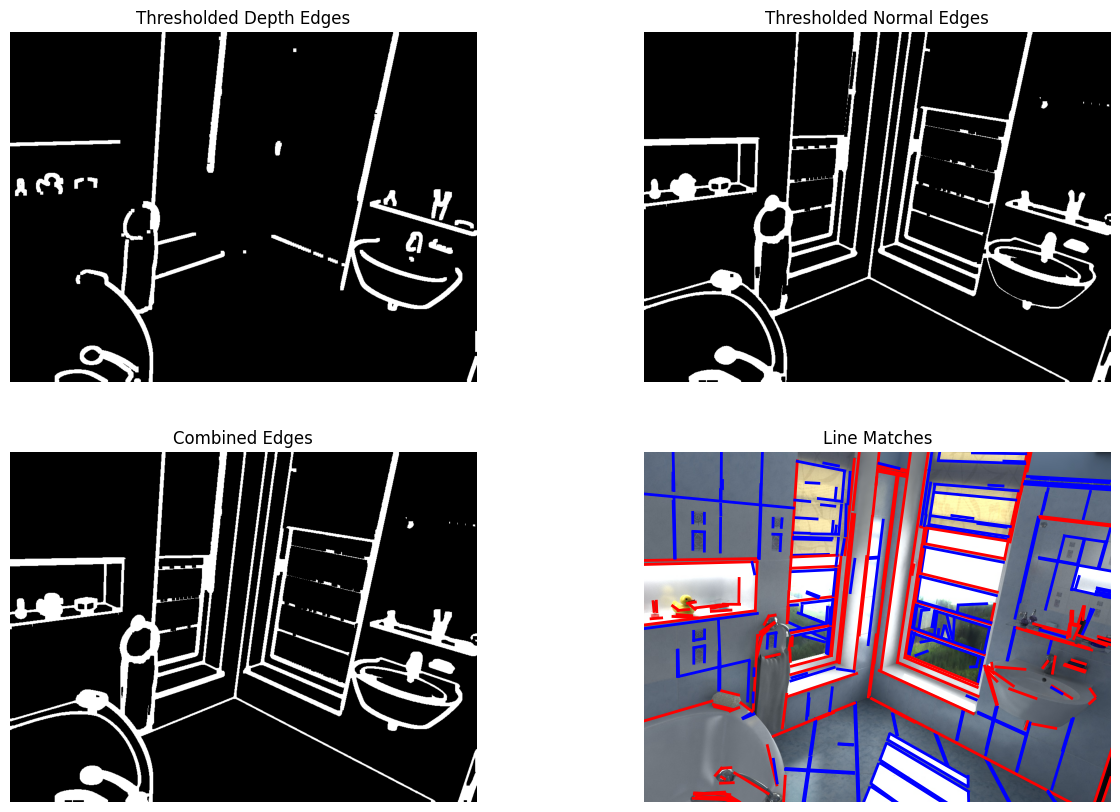

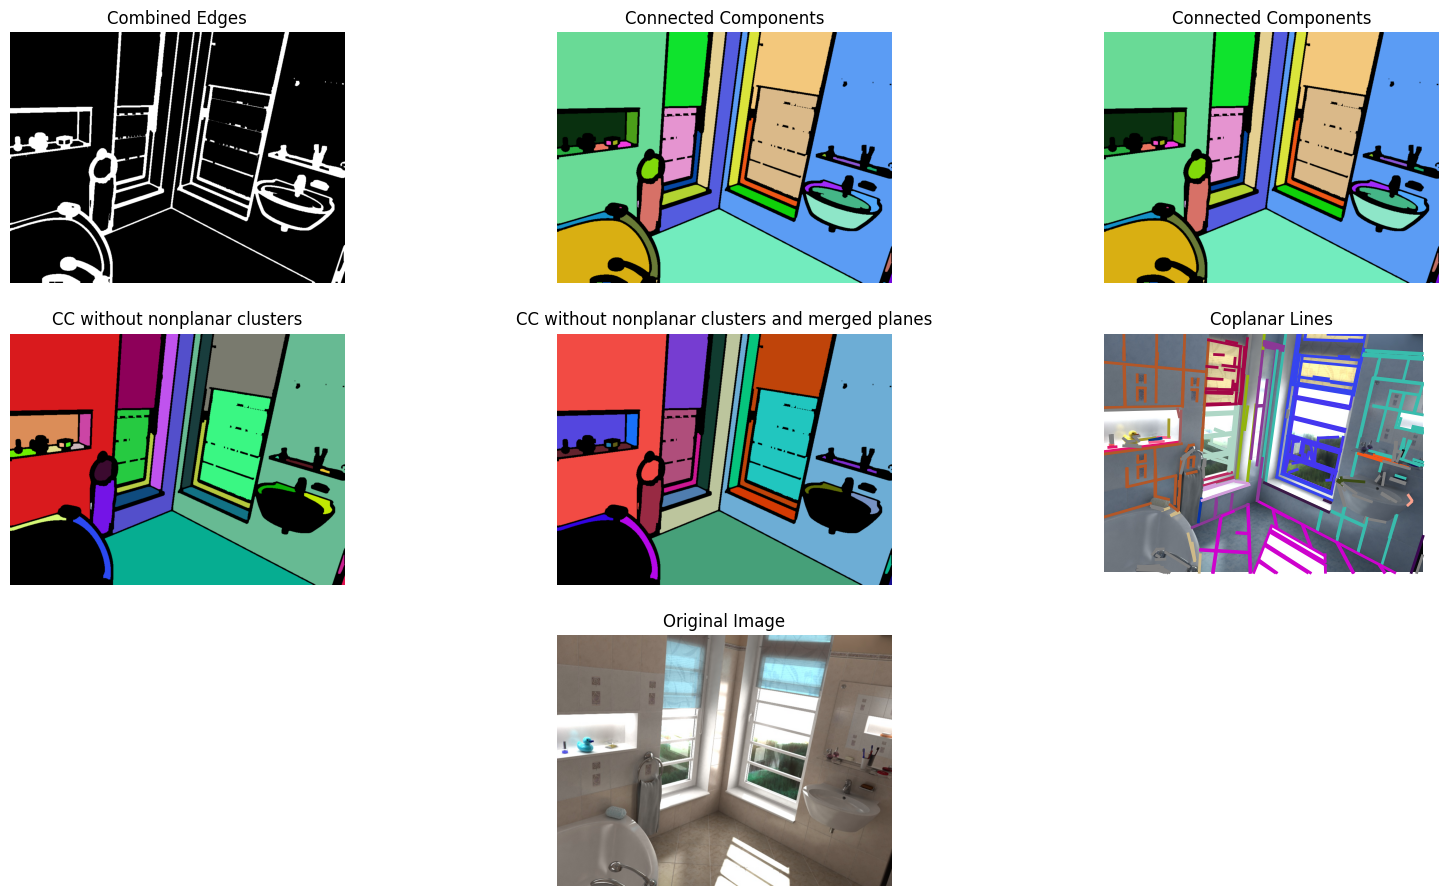

Start : 1744831230.9323301
???
Time to get depth and calculate normal map and wd : 0.10001993179321289
Time for DeepLSD : 0.4678776264190674
Time to calculate variation edges : 0.07298660278320312
Time for structural vs textural : 0.09417271614074707
Time for line data structure creation : 0.002728700637817383
Time to get CC : 0.0012507438659667969
Number of connected components (including background): 98
Time to run Ransac : 0.3063833713531494
Number of connected components (including background): 98
Time to filter and merge plans : 0.2531747817993164
Time before plotting : 1.2988362312316895


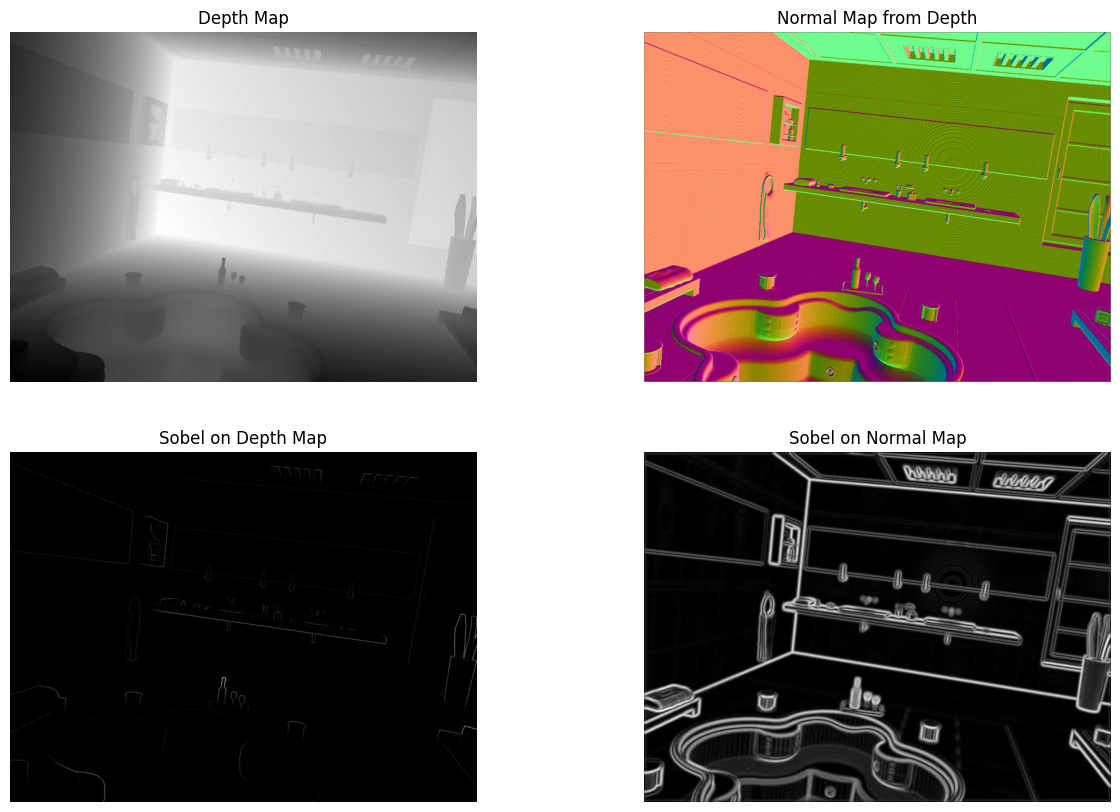

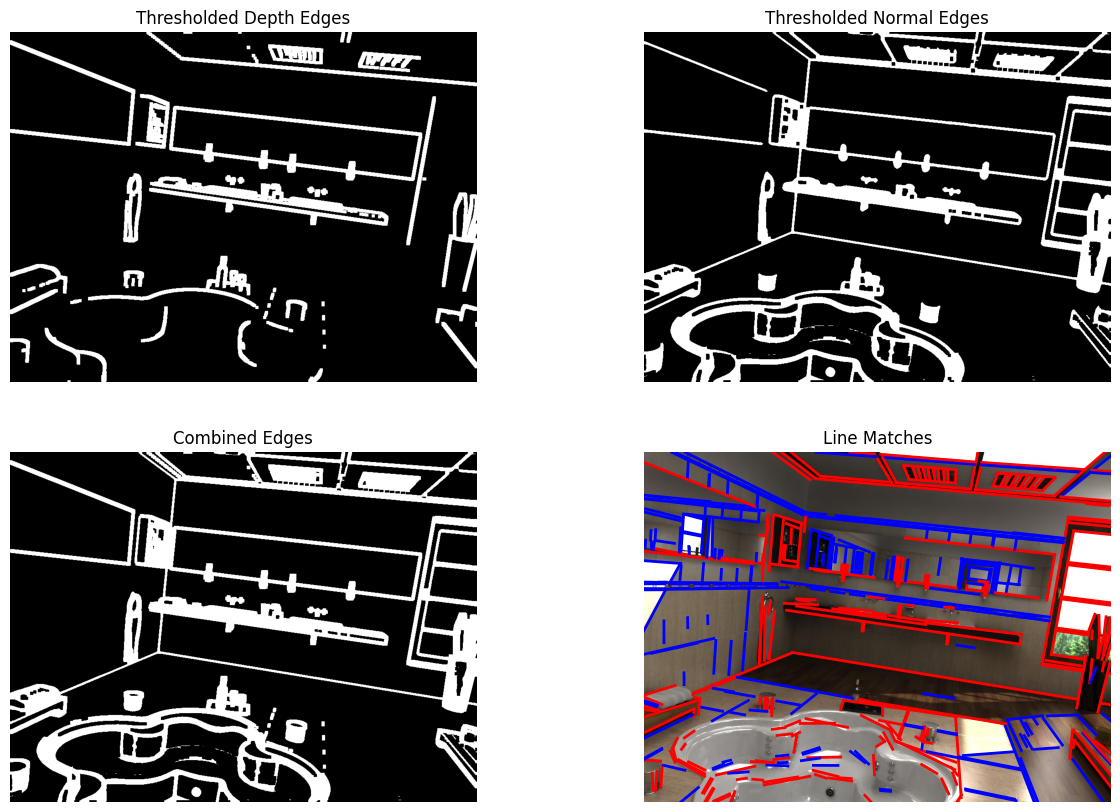

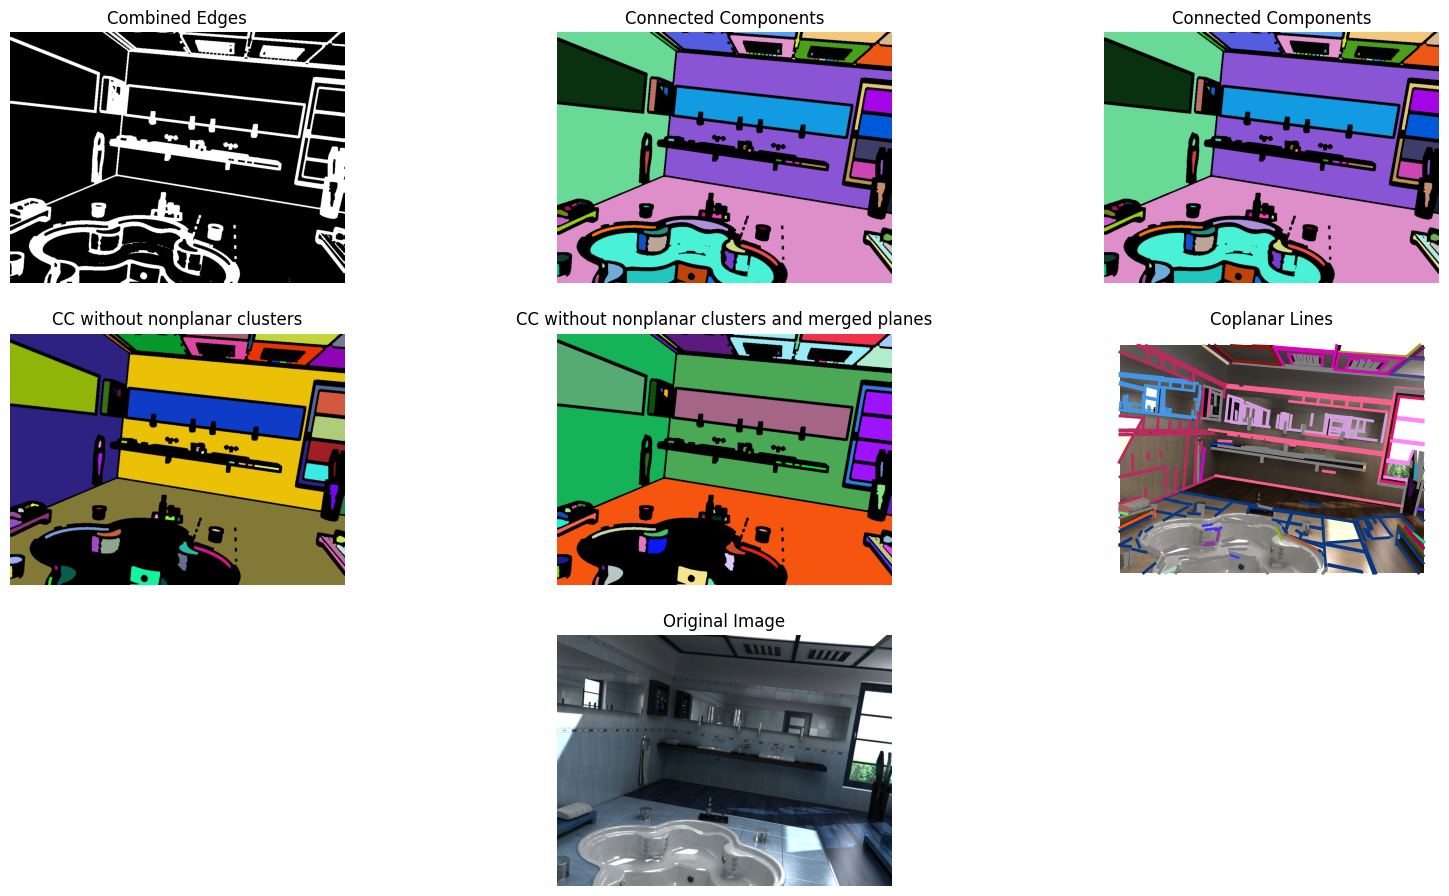

Start : 1744831234.0823958
???
Time to get depth and calculate normal map and wd : 0.10889434814453125
Time for DeepLSD : 0.4942896366119385
Time to calculate variation edges : 0.07642054557800293
Time for structural vs textural : 0.08613729476928711
Time for line data structure creation : 0.0027892589569091797
Time to get CC : 0.0012133121490478516
Number of connected components (including background): 64
Time to run Ransac : 0.3473029136657715
Number of connected components (including background): 64
Time to filter and merge plans : 0.17912983894348145
Time before plotting : 1.2966768741607666


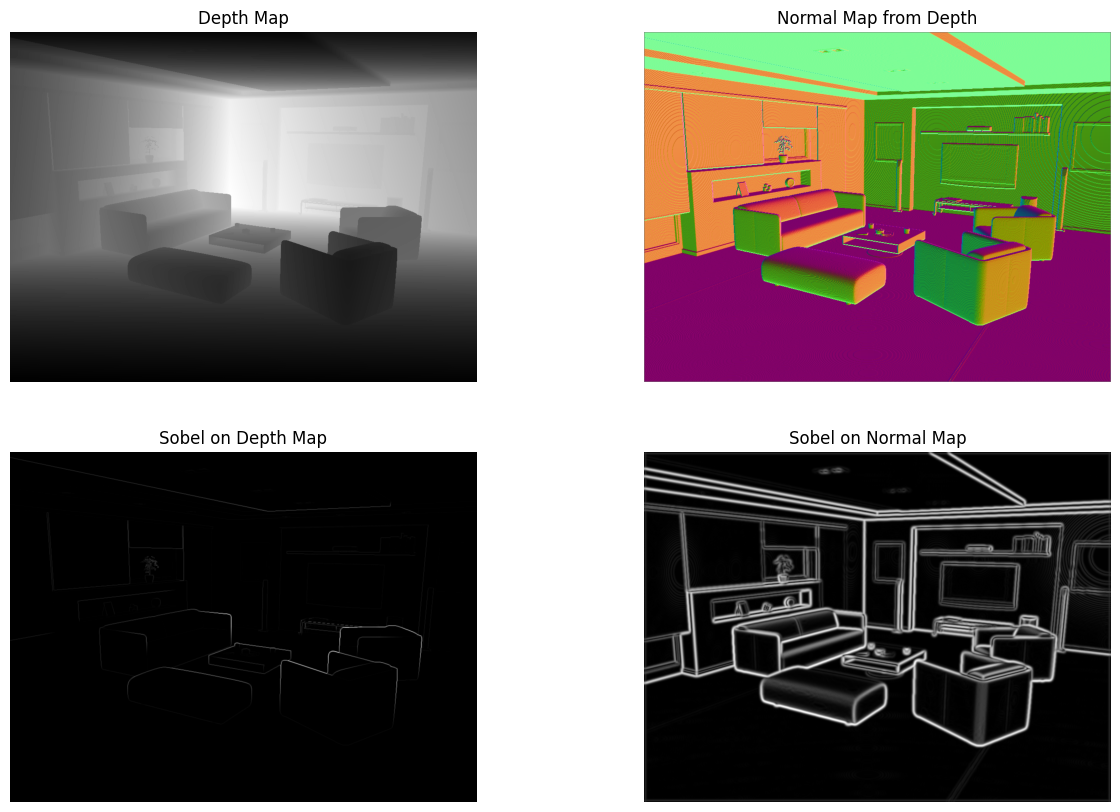

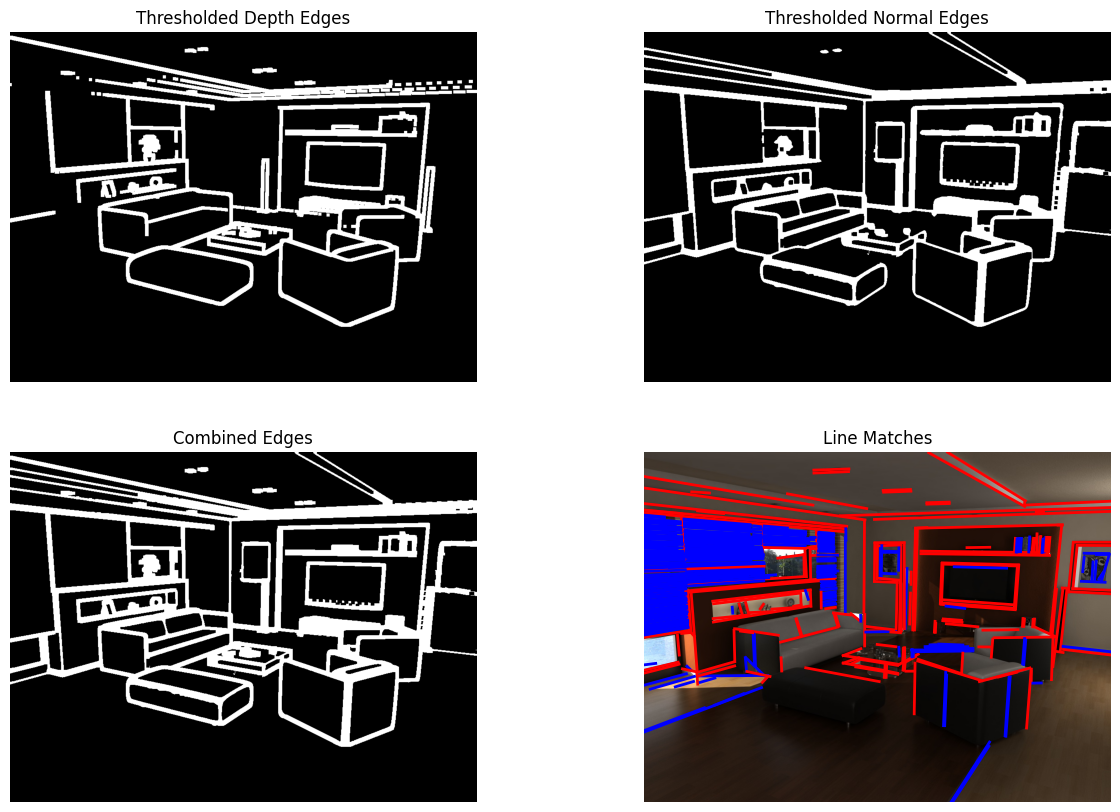

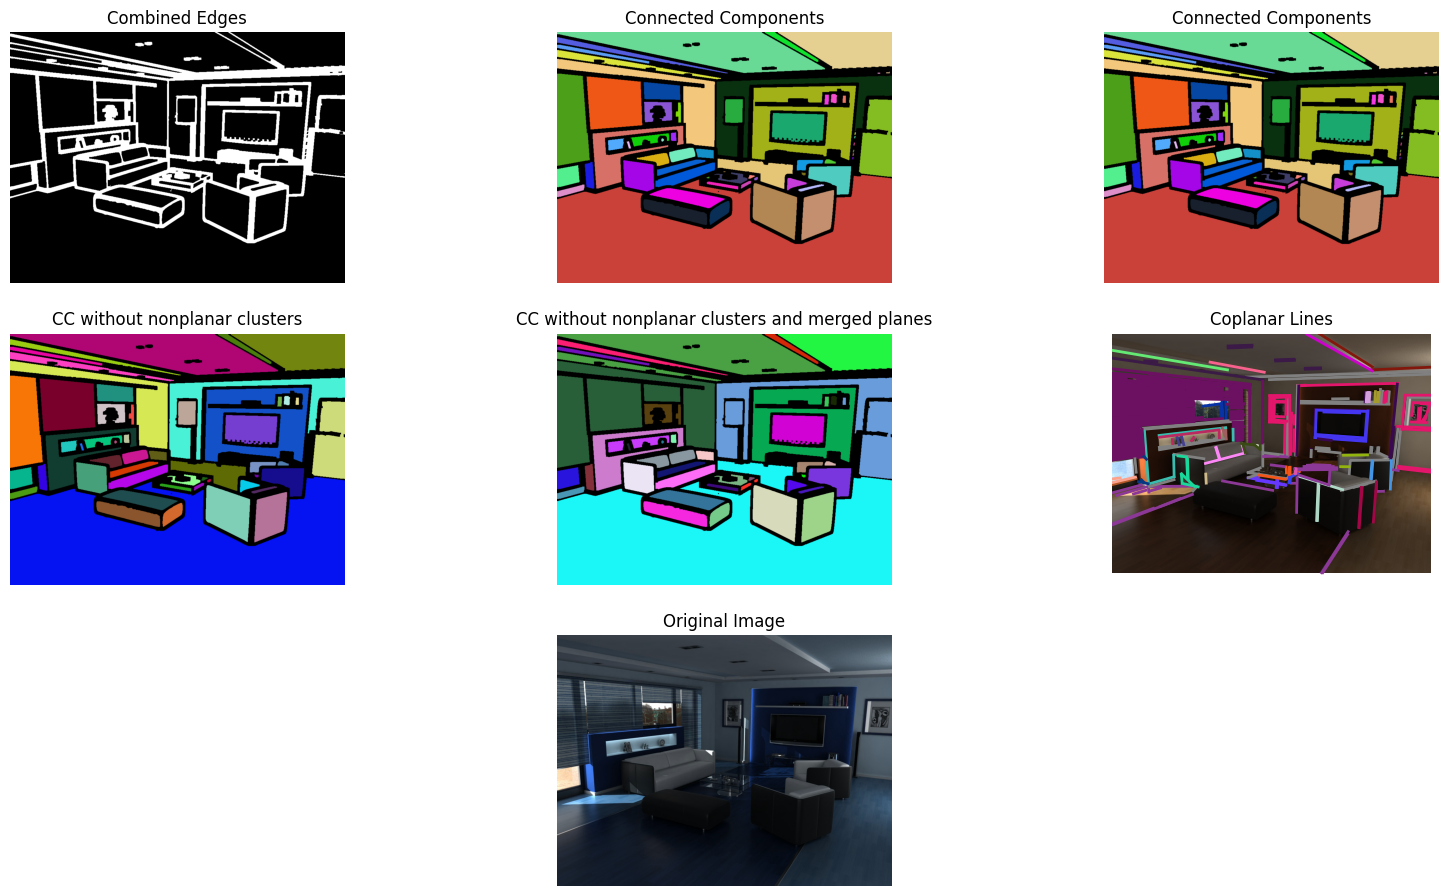

Start : 1744831237.00074
???
Time to get depth and calculate normal map and wd : 0.09132552146911621
Time for DeepLSD : 0.521080493927002
Time to calculate variation edges : 0.07889604568481445
Time for structural vs textural : 0.03754472732543945
Time for line data structure creation : 0.0013661384582519531
Time to get CC : 0.0013599395751953125
Number of connected components (including background): 46
Time to run Ransac : 0.3624298572540283
Number of connected components (including background): 46
Time to filter and merge plans : 0.13361501693725586
Time before plotting : 1.2278718948364258


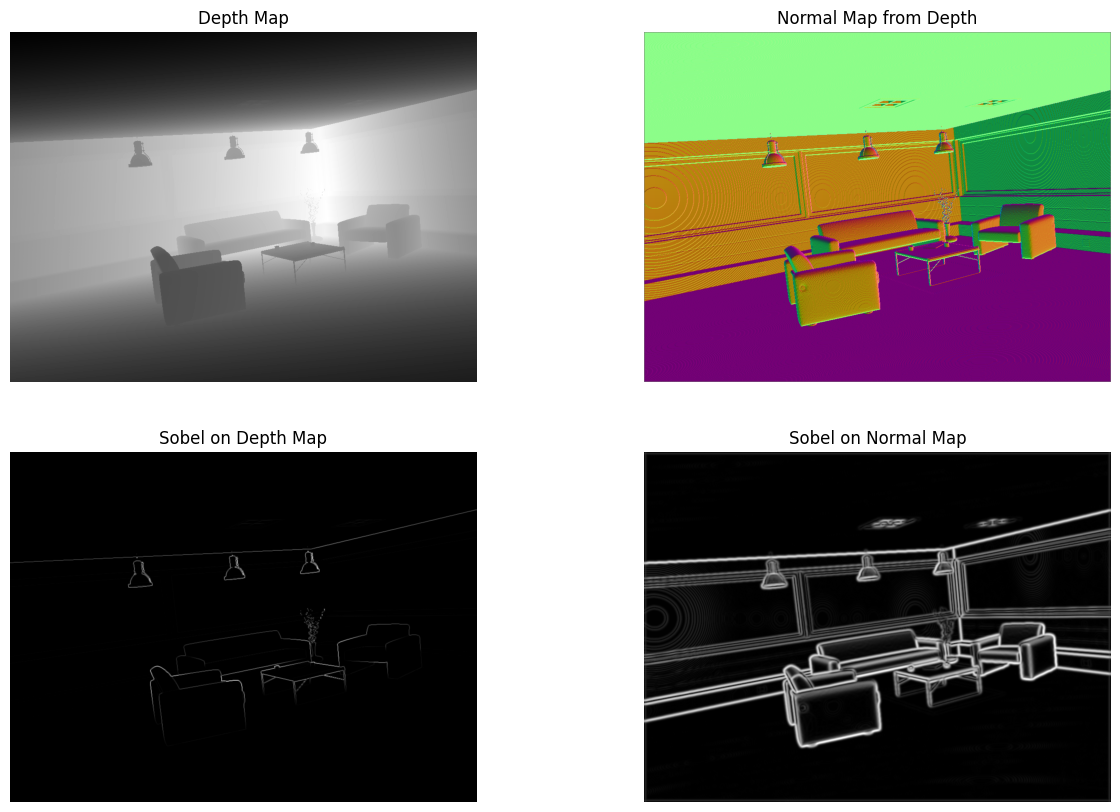

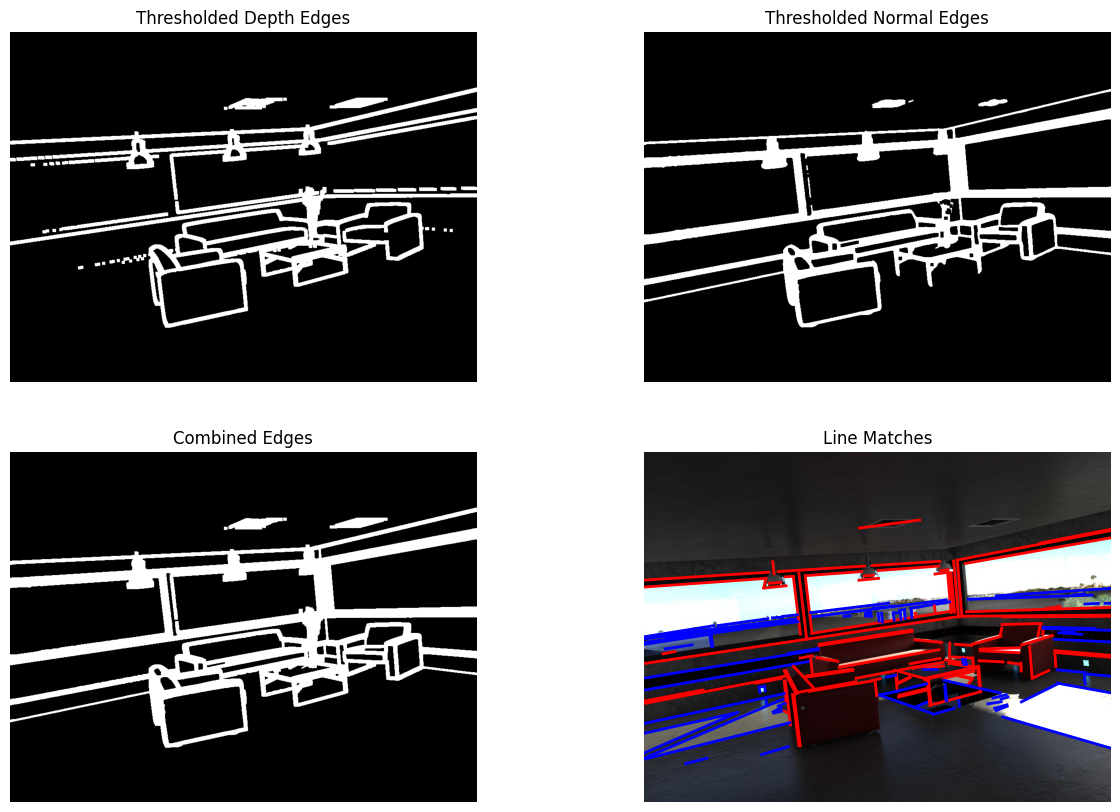

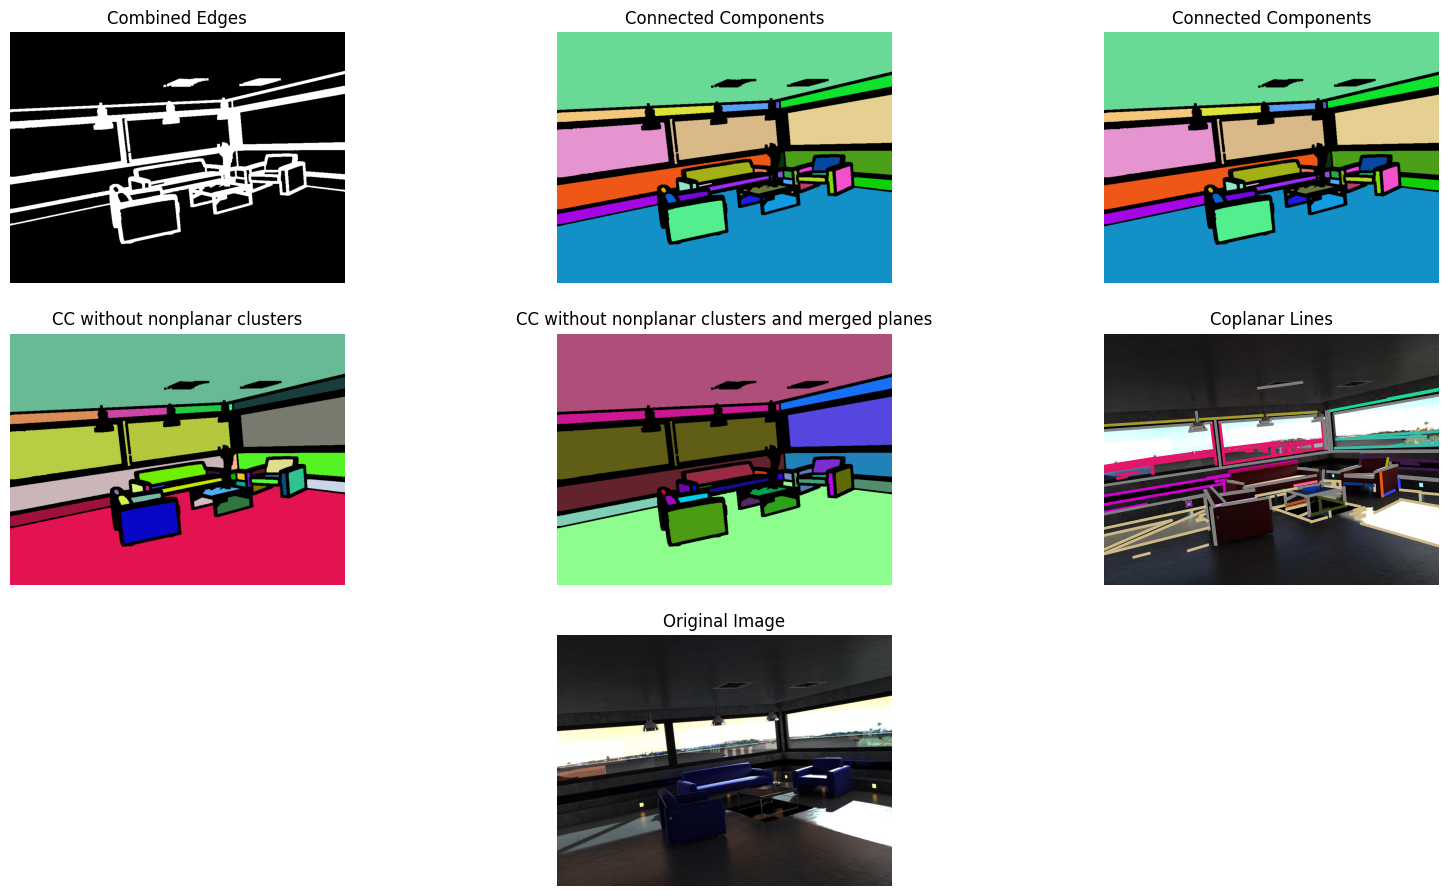

Start : 1744831239.6339722
???
Time to get depth and calculate normal map and wd : 0.13021349906921387
Time for DeepLSD : 0.5011096000671387
Time to calculate variation edges : 0.07571029663085938
Time for structural vs textural : 0.09605598449707031
Time for line data structure creation : 0.0025000572204589844
Time to get CC : 0.0012691020965576172
Number of connected components (including background): 106
Time to run Ransac : 0.3167695999145508
Number of connected components (including background): 106
Time to filter and merge plans : 0.35390472412109375
Time before plotting : 1.47774076461792


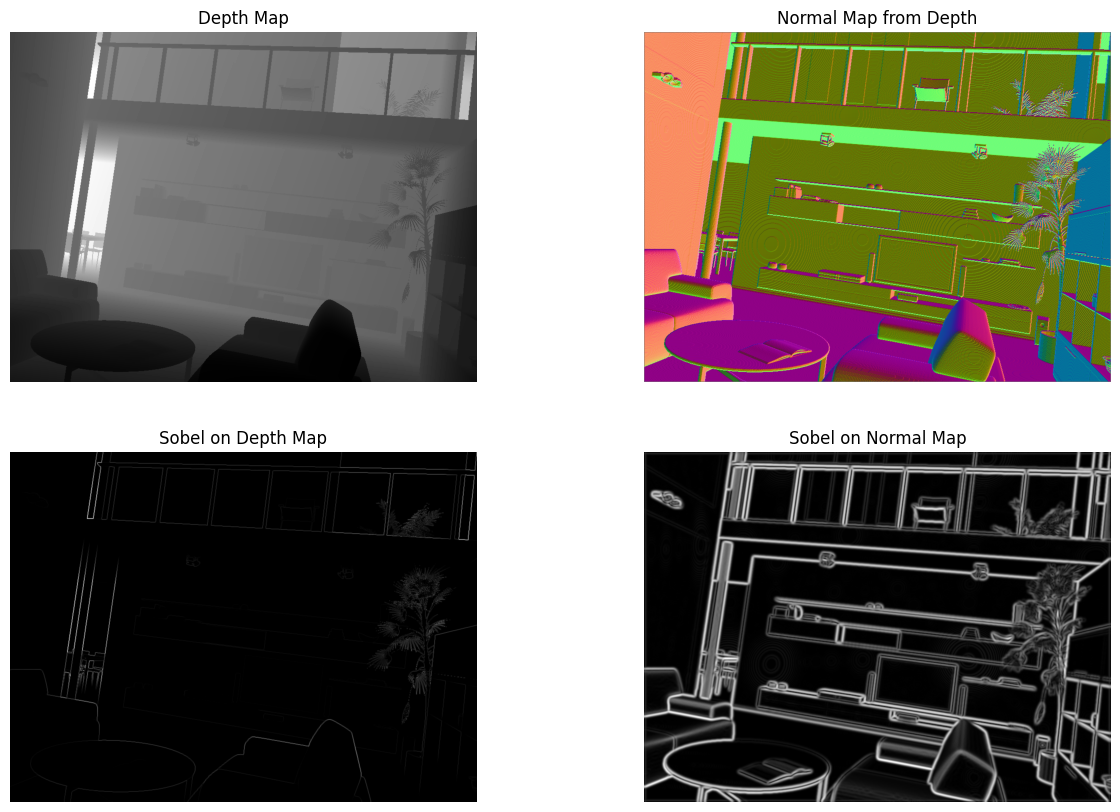

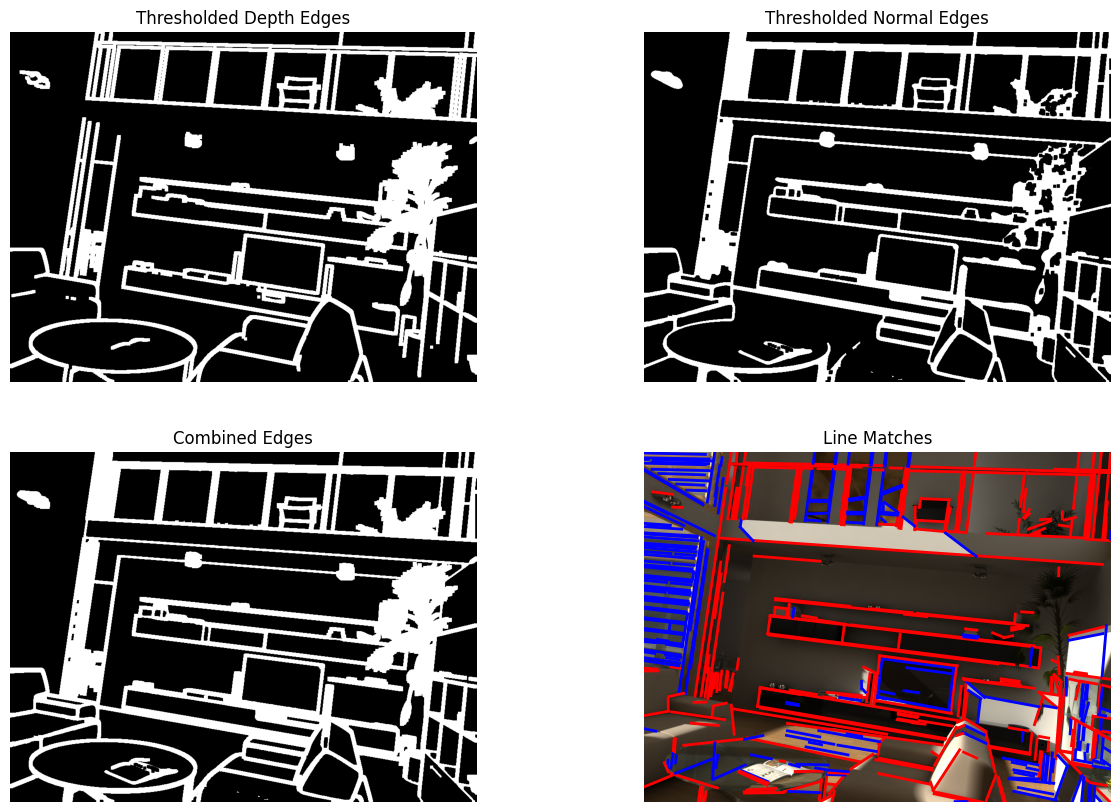

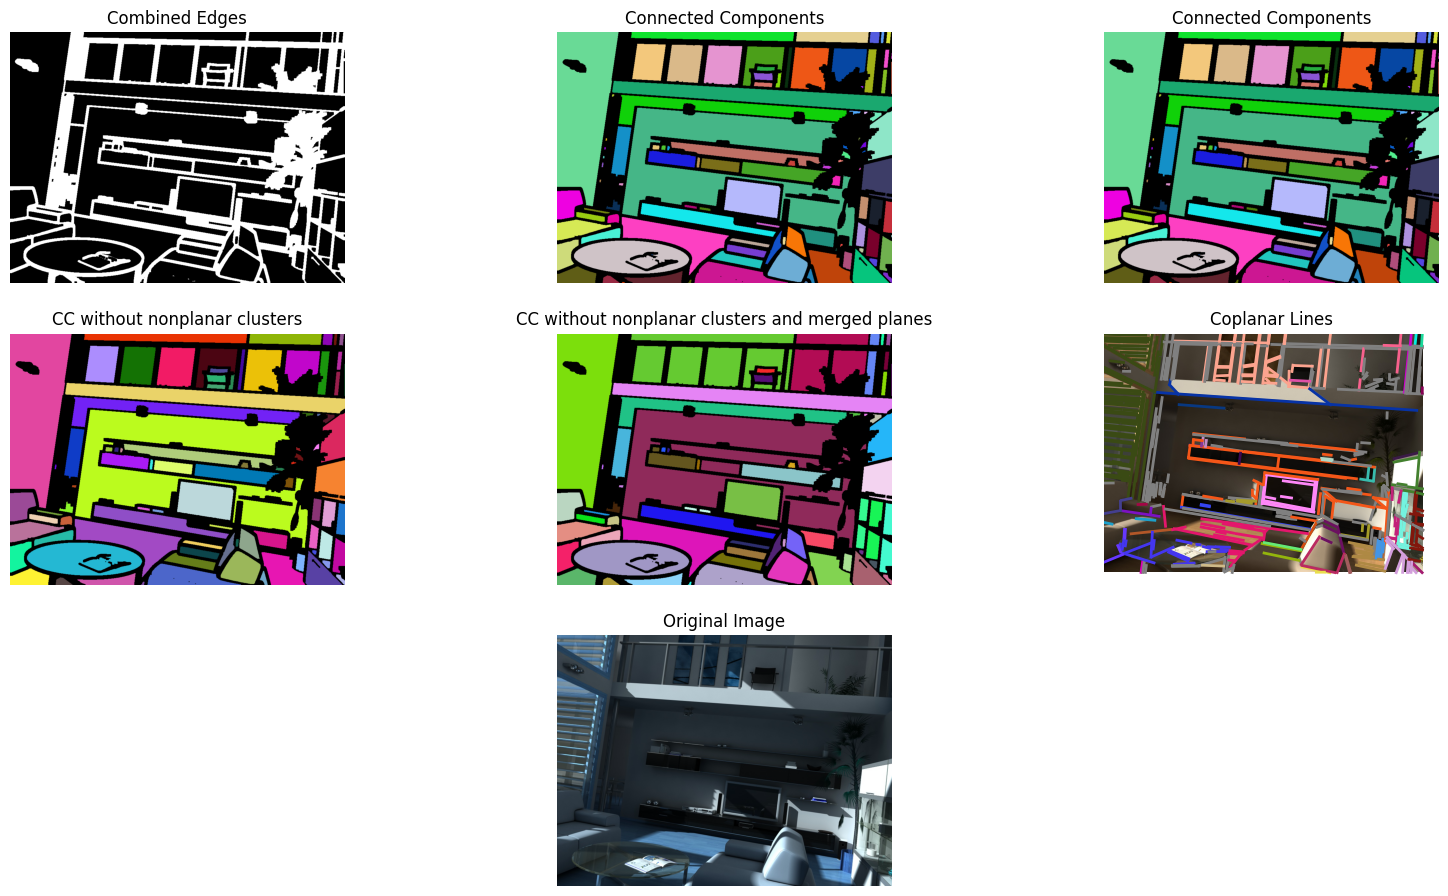

In [205]:
frame_str = "0001"
desired_images = [
    "ai_001_001",
    # "ai_001_004",
    # "ai_001_005",
    # "ai_001_006",
    "ai_001_007",
    "ai_001_008",
    "ai_001_009",
    "ai_002_001",

    #"DSC_0442",
    #"DSC_0455",
    #"DSC_0239",
    #"DSC_0249",
]

#moge = MoGeModel.from_pretrained("Ruicheng/moge-vitl").to(device)

# Process, plot, and save JSON data for each image.
for image_id in desired_images:
    #composite_after, pred_lines, img, normals, world_coordinates, valid_mask, line_info, scores, isstruct, original_lines
    # Load the model from huggingface hub (or load from local).
    image_dir = os.path.join("data", image_id)
    composite_after, pred_lines, img, normals, world_coordinates, valid_mask, line_info, scores, isstruct, original_lines = process_image(
        image_dir, image_id, frame_str, net, device,
        depth_thresh=50, normal_thresh=1.5 * 1e7,
        dataset="hypersim"
        #moge_model = moge
    )
    